<a href="https://colab.research.google.com/github/davinalifianda123/pengolahan_citra_smt4/blob/main/Jobsheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 1. Transormasi Kurva (Citra Negatif)

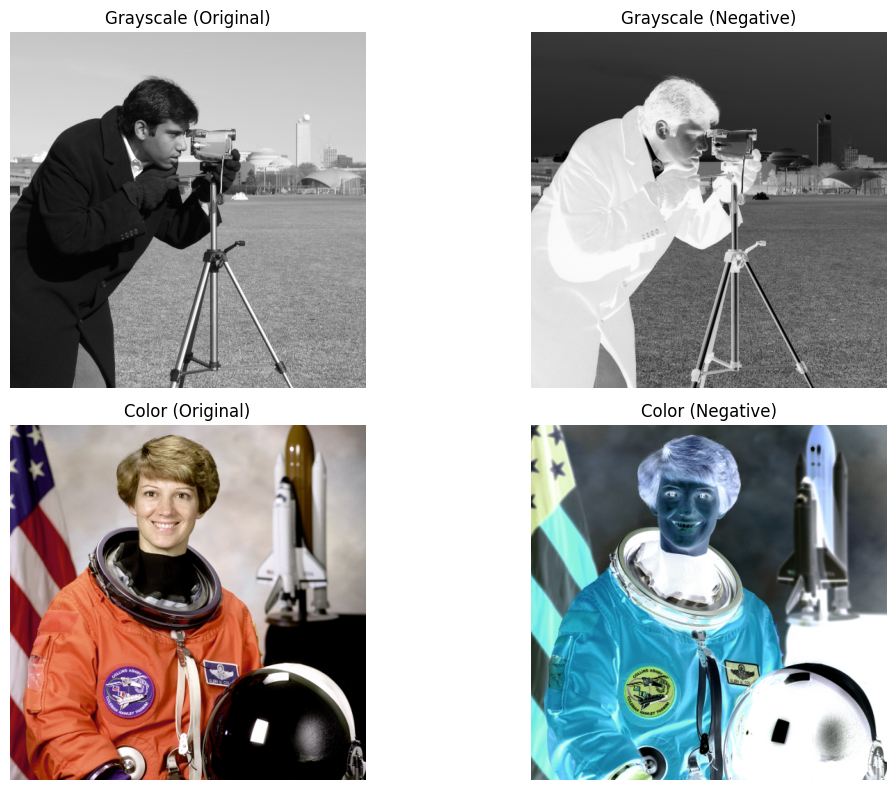

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)

negative_gray = 1.0 - image_gray_float

image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)

negative_color = 1.0 - image_color_float

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

#Praktikum 2. Histogram dan Ekualisasi Histogram

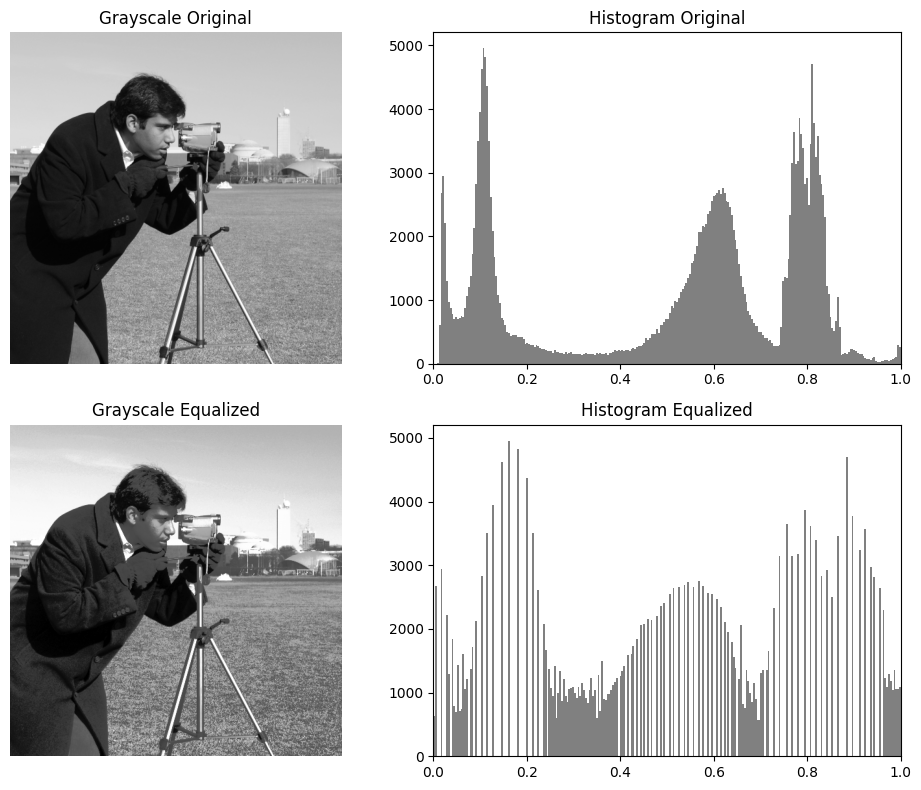

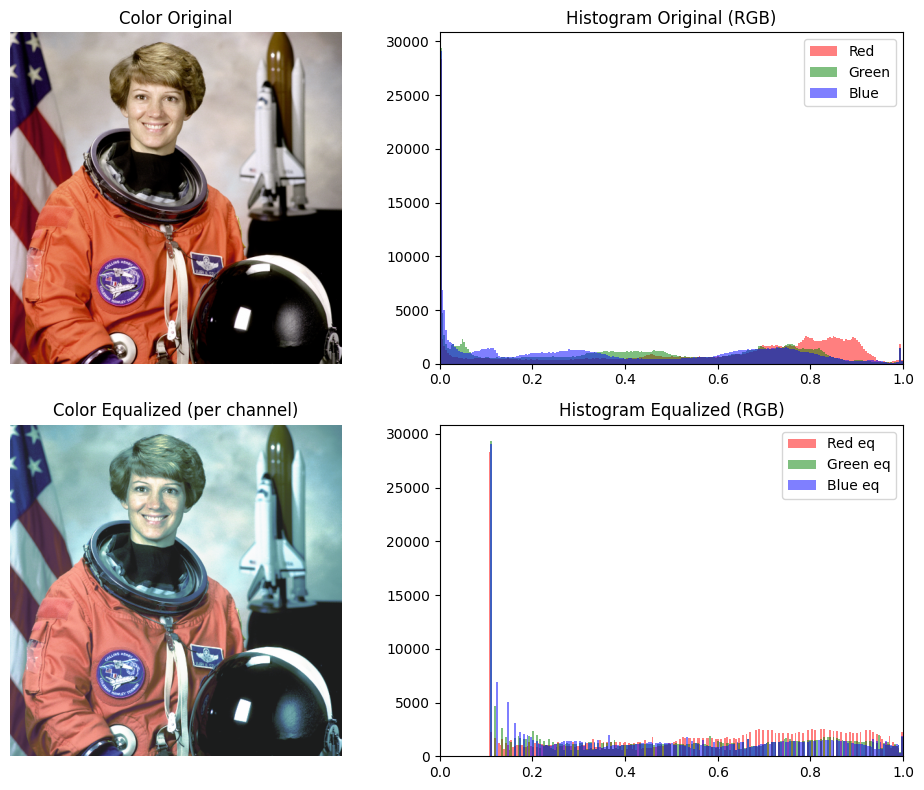

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)

hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0,1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]

hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

image_color_eq = np.dstack((r_eq, g_eq, b_eq))

hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend(loc='upper right')

axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0,1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

#Praktikum 3. Konvolusi (Filter Rata-rata)

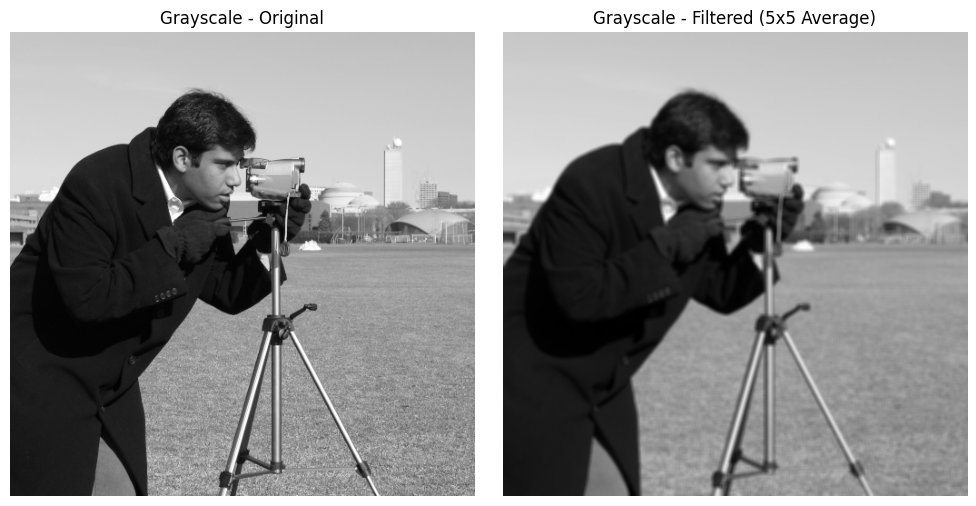

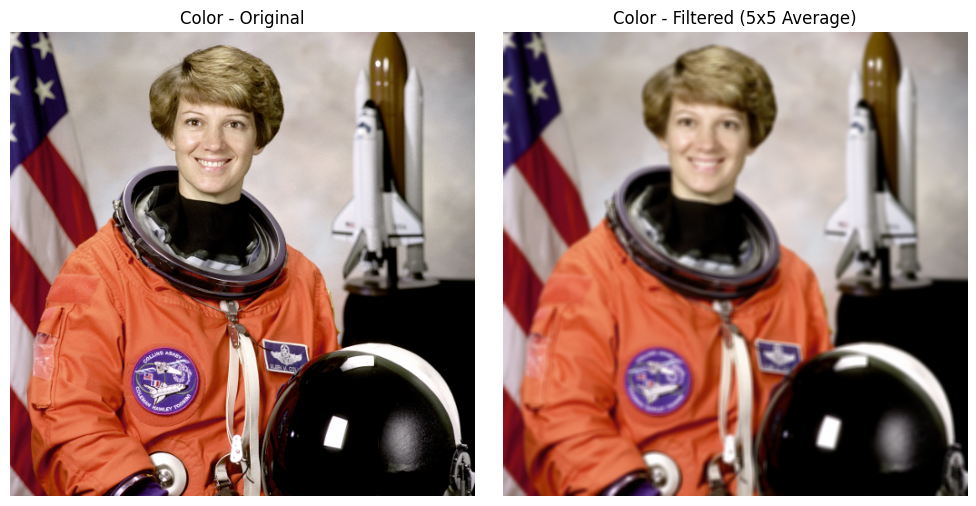

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

gray_uint8 = data.camera()
gray_img = img_as_float(gray_uint8)

kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

color_uint8 = data.astronaut()
color_img = img_as_float(color_uint8)

color_filtered = np.zeros_like(color_img)

for c in range(3):
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

#Praktikum 4. Filter Median (penghilangan noise/derau)

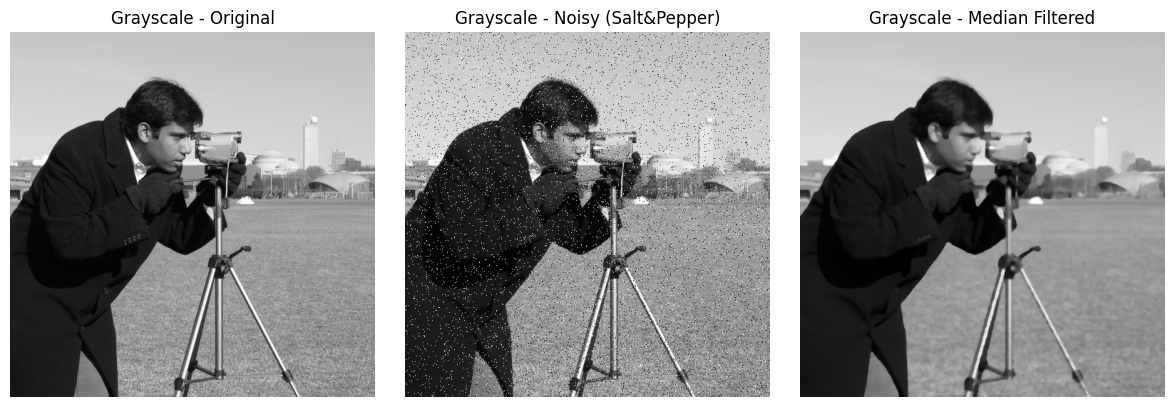

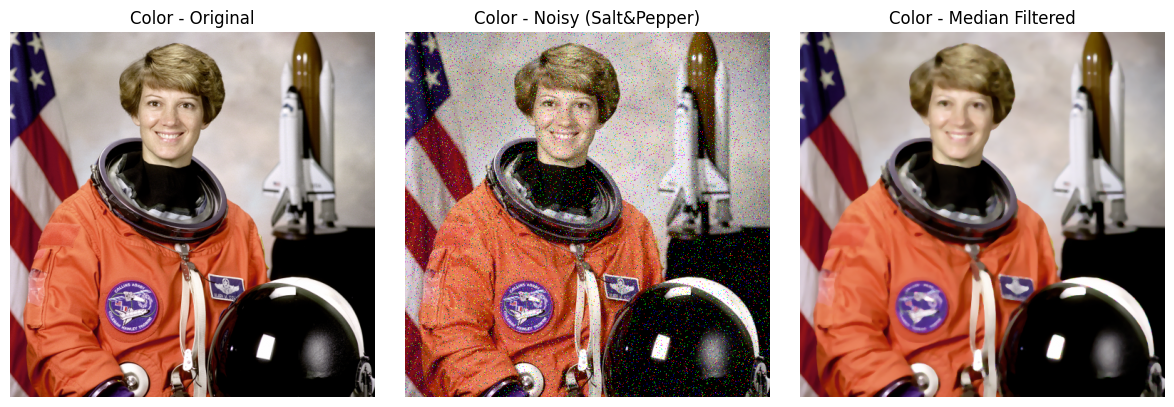

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

gray_uint8 = data.camera()
gray_float = img_as_float(gray_uint8)

gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)

disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

color_uint8 = data.astronaut()
color_float = img_as_float(color_uint8)

color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

#Eksperimen Transformasi Intensitas Lain

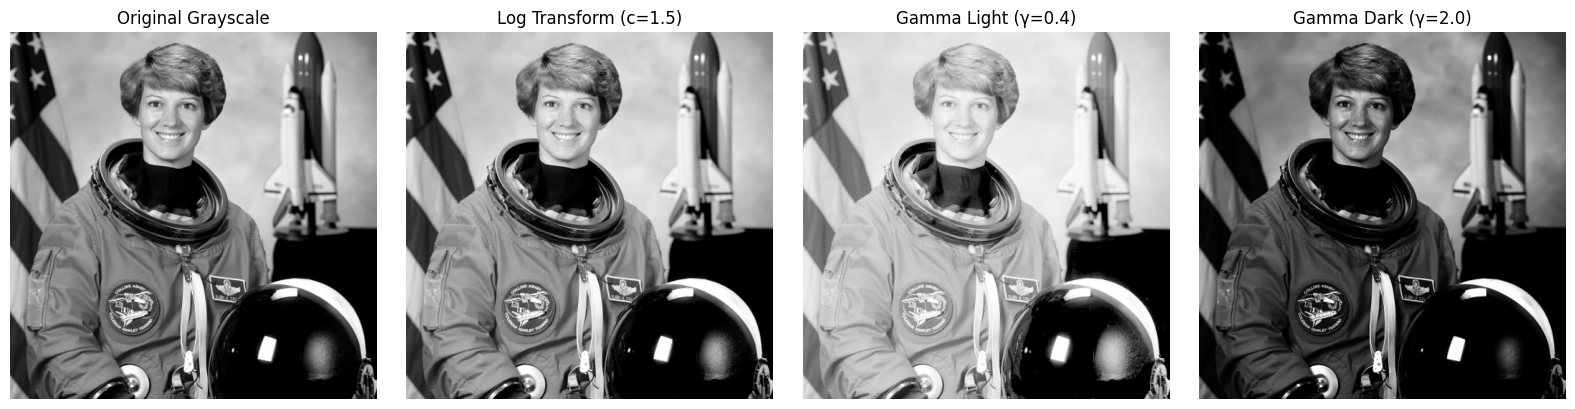

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

rgb_image = data.astronaut()
gray_image = color.rgb2gray(rgb_image)
gray_image = img_as_float(gray_image)

c_log = 1.5
log_transformed = c_log * np.log1p(gray_image)
log_transformed /= log_transformed.max()

gamma_low = 0.4  # cerahkan
gamma_high = 2.0  # gelapkan
gamma_light = exposure.adjust_gamma(gray_image, gamma=gamma_low, gain=1)
gamma_dark = exposure.adjust_gamma(gray_image, gamma=gamma_high, gain=1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title("Original Grayscale")
axes[0].axis('off')

axes[1].imshow(log_transformed, cmap='gray')
axes[1].set_title(f"Log Transform (c={c_log})")
axes[1].axis('off')

axes[2].imshow(gamma_light, cmap='gray')
axes[2].set_title(f"Gamma Light (γ={gamma_low})")
axes[2].axis('off')

axes[3].imshow(gamma_dark, cmap='gray')
axes[3].set_title(f"Gamma Dark (γ={gamma_high})")
axes[3].axis('off')

plt.tight_layout()
plt.show()

#Perbandingan Metode Peningkatan Kontras

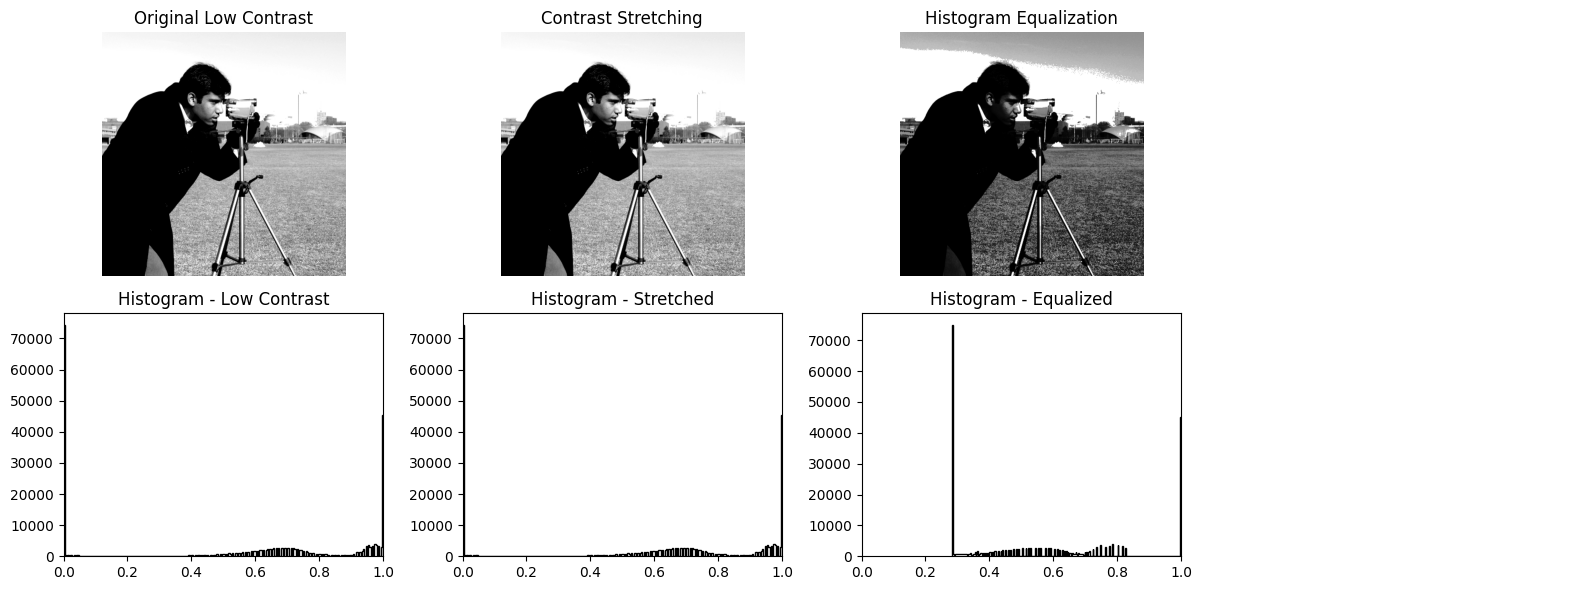

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

image = img_as_float(data.camera())

low_contrast = exposure.rescale_intensity(image, in_range=(0.2, 0.8))

# 1. Contrast Stretching
stretched = exposure.rescale_intensity(low_contrast, in_range='image', out_range=(0, 1))

# 2. Histogram Equalization
equalized = exposure.equalize_hist(low_contrast)

def plot_hist(ax, image, title):
    ax.hist(image.ravel(), bins=256, histtype='step', color='black')
    ax.set_title(title)
    ax.set_xlim(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

axes[0, 0].imshow(low_contrast, cmap='gray')
axes[0, 0].set_title("Original Low Contrast")
axes[0, 0].axis('off')

axes[0, 1].imshow(stretched, cmap='gray')
axes[0, 1].set_title("Contrast Stretching")
axes[0, 1].axis('off')

axes[0, 2].imshow(equalized, cmap='gray')
axes[0, 2].set_title("Histogram Equalization")
axes[0, 2].axis('off')

axes[0, 3].axis('off')

plot_hist(axes[1, 0], low_contrast, "Histogram - Low Contrast")
plot_hist(axes[1, 1], stretched, "Histogram - Stretched")
plot_hist(axes[1, 2], equalized, "Histogram - Equalized")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

#Filter Median vs Filter Rata-rata

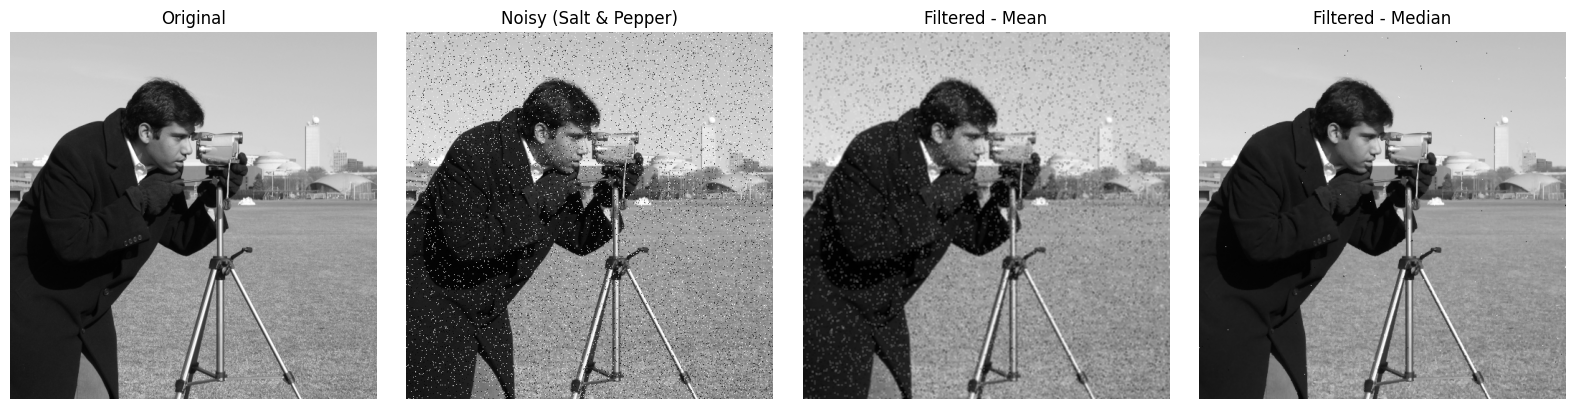

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, util, filters, morphology
from scipy import ndimage as ndi

image = img_as_float(data.camera())

noisy = util.random_noise(image, mode='s&p', amount=0.05)

kernel_size = 3
kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
mean_filtered = ndi.convolve(noisy, kernel, mode='reflect')

# bisa pakai Gaussian Filter sebagai alternatif smoothing

median_filtered = filters.median(noisy, morphology.disk(1))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title("Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title("Filtered - Mean")
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Filtered - Median")
axes[3].axis('off')

plt.tight_layout()
plt.show()